<a href="https://colab.research.google.com/github/maribelvillagrasa-star/tfm-riesgo-cardiovascular-genero/blob/main/notebooks/tfm_riesgo_cardiovascular_genero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install statsmodels shap --quiet

In [2]:
import numpy, pandas, sklearn, shap, statsmodels, matplotlib, seaborn
for m in (numpy, pandas, sklearn, shap, statsmodels, matplotlib, seaborn):
    print(f"{m.__name__}=={m.__version__}")

numpy==2.1.3
pandas==2.2.3
sklearn==1.6.1
shap==0.52.0
statsmodels==0.15.0
matplotlib==3.10.0
seaborn==0.13.2


Successfully loaded data from https://raw.githubusercontent.com/maribelvillagrasa-star/tfm-riesgo-cardiovascular-genero/main/data/heart.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Dimensiones del dataset: (303, 15)

Tipos de datos:
 age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
target        int64
dtype: object

Valores nulos por columna:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
target      0
dtype: int64

--- Estadística descriptiva ---
          count        mean        std    min    25%    50%    75%    max
age       303.0   54.438944   9.038662   29.0   48.0   56.0   61.0   77.0
sex       303.0    0.679868   0.467299    0.0    0.0    1.0    1.0    1.0
cp        303.0    3.158416   0.960126    1.0    3.0    3.0    4.0    4.0
trestbps  303.0  131.689769  17.599748   94.0  120.0

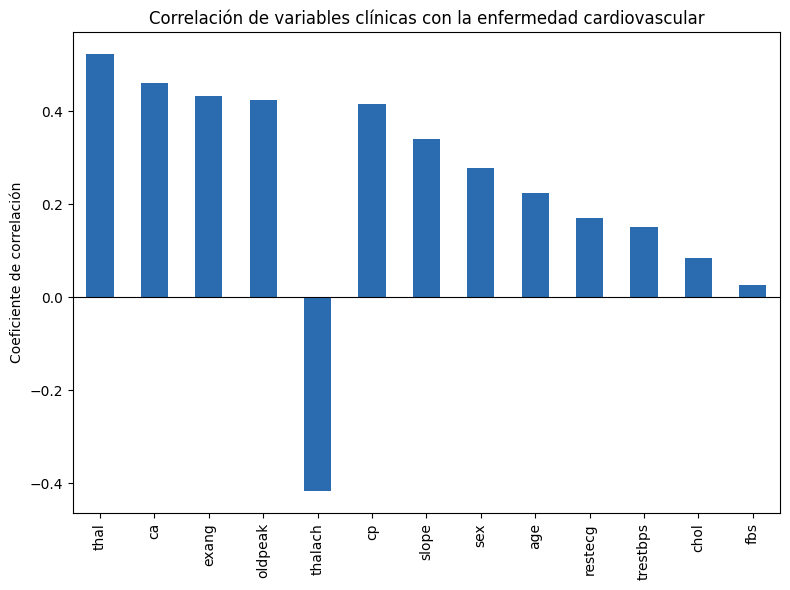

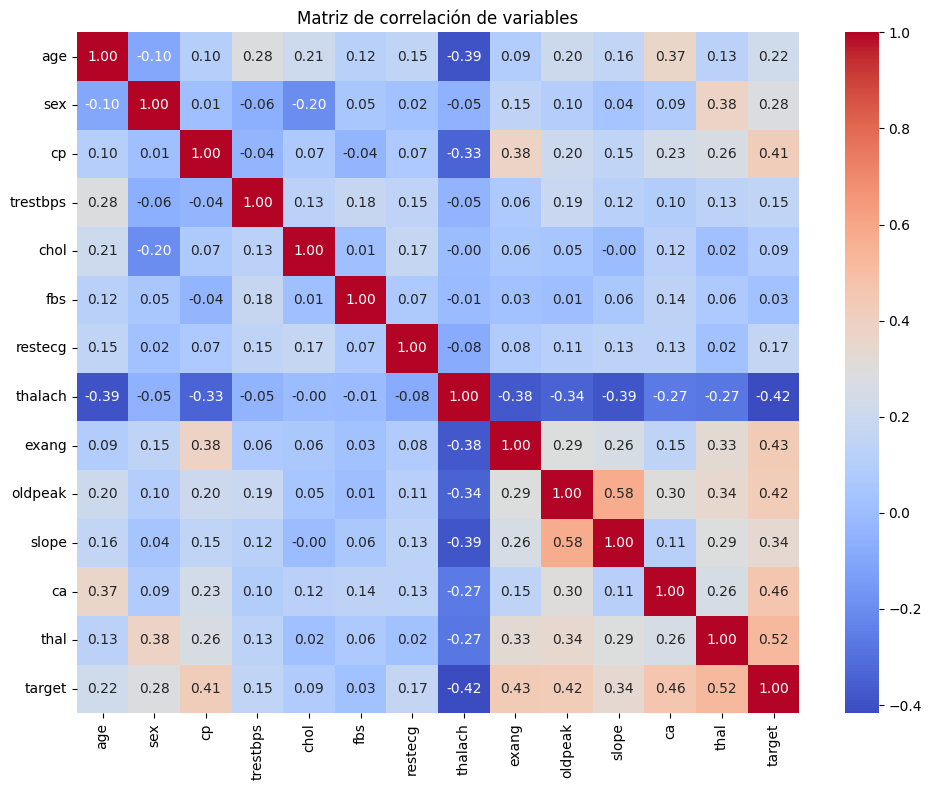

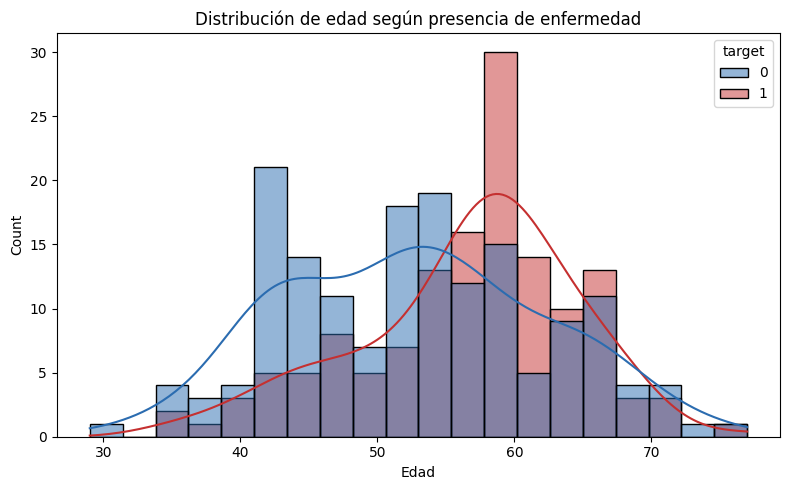


--- Distribución por sexo (%) ---
sexo_label
Hombre    67.986799
Mujer     32.013201
Name: proportion, dtype: float64

--- Prevalencia de enfermedad por sexo ---
sexo_label
Hombre    55.339806
Mujer     25.773196
Name: target, dtype: float64

--- Tabla de contingencia sexo x target ---
target       0    1
sexo_label         
Hombre      92  114
Mujer       72   25

--- Medias de variables clínicas por sexo ---
                  age    trestbps        chol     thalach   oldpeak
sexo_label                                                         
Hombre      53.834951  130.912621  239.601942  148.844660  1.120874
Mujer       55.721649  133.340206  261.752577  151.226804  0.867010


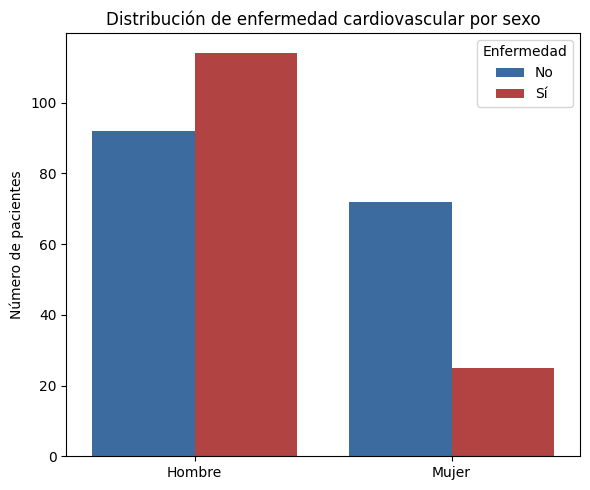

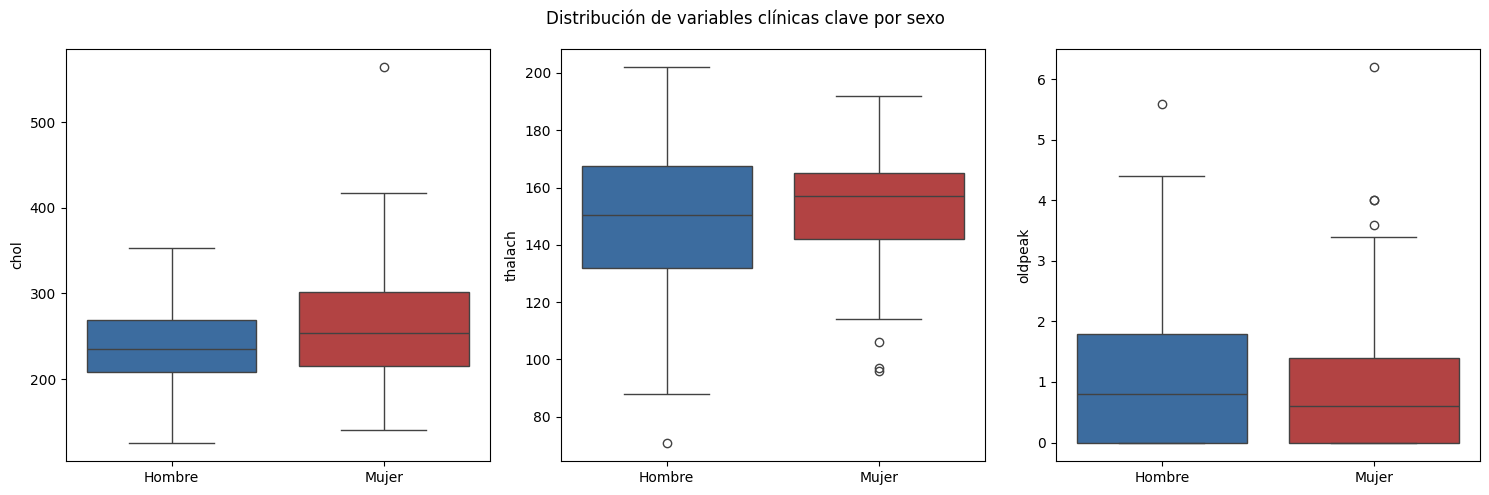

In [3]:
"""
TFM - Clasificación de enfermedad cardiovascular mediante IA: una perspectiva de género
Fase 5: Análisis Exploratorio de Datos (EDA)

Dataset: heart.csv (UCI Heart Disease - Cleveland)

Este script realiza el análisis exploratorio de datos (EDA) sobre heart.csv:
carga el dataset, calcula estadística descriptiva básica, estudia la
correlación de cada variable clínica con la presencia de enfermedad
cardiovascular (variable objetivo binarizada 'target'), y genera 5 figuras
(correlación con target, matriz de correlación completa, distribución de
edad, distribución de enfermedad por sexo y boxplots de variables clave por
sexo). El apartado final analiza específicamente las diferencias entre
hombres y mujeres en el dataset, que es el punto de partida del enfoque de
género del TFM.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Definición del path del TFM (el dataset se lee directamente desde el repositorio de GitHub)
data_path = 'https://raw.githubusercontent.com/maribelvillagrasa-star/tfm-riesgo-cardiovascular-genero/main/data/heart.csv'

try:

# 3. Carga de datos
    df = pd.read_csv(data_path)
    print(f"Successfully loaded data from {data_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{data_path}' was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An error occurred: {e}")

# Variable objetivo binarizada: 0 = sin enfermedad, 1 = con enfermedad (grados 1-4)
df["target"] = (df["num"] > 0).astype(int)

print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:\n", df.dtypes)
print("\nValores nulos por columna:\n", df.isna().sum())

# ---------------------------------------------------------
# 5.1. Estadística descriptiva
# ---------------------------------------------------------
print("\n--- Estadística descriptiva ---")
print(df.describe().T)

print("\n--- Distribución de la variable objetivo (num) ---")
print(df["num"].value_counts().sort_index())

print("\n--- Distribución de la variable objetivo binarizada (target) ---")
print(df["target"].value_counts())

# ---------------------------------------------------------
# 5.2. Distribución de variables y correlaciones
# ---------------------------------------------------------
corr_target = (
    df.corr(numeric_only=True)["target"]
    .drop(["target", "num"])
    .sort_values(key=abs, ascending=False)
)
print("\n--- Correlación de variables con target ---")
print(corr_target)

# Gráfico de correlaciones con la variable objetivo
plt.figure(figsize=(8, 6))
corr_target.plot(kind="bar", color="#2b6cb0")
plt.title("Correlación de variables clínicas con la enfermedad cardiovascular")
plt.ylabel("Coeficiente de correlación")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("fig_correlacion_target.png", dpi=150)
plt.show()
plt.close()

# Matriz de correlación completa (heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=["num"]).corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación de variables")
plt.tight_layout()
plt.savefig("fig_matriz_correlacion.png", dpi=150)
plt.show()
plt.close()

# Distribución de edad
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", hue="target", kde=True, bins=20, palette=["#2b6cb0", "#c53030"])
plt.title("Distribución de edad según presencia de enfermedad")
plt.xlabel("Edad")
plt.tight_layout()
plt.savefig("fig_distribucion_edad.png", dpi=150)
plt.show()
plt.close()

# ---------------------------------------------------------
# 5.3. Análisis diferencial por sexo
# ---------------------------------------------------------
# Nota: sex = 1.0 -> hombre, sex = 0.0 -> mujer (codificación original del dataset UCI)
df["sexo_label"] = df["sex"].map({1.0: "Hombre", 0.0: "Mujer"})

print("\n--- Distribución por sexo (%) ---")
print(df["sexo_label"].value_counts(normalize=True) * 100)

print("\n--- Prevalencia de enfermedad por sexo ---")
print(df.groupby("sexo_label")["target"].mean() * 100)

print("\n--- Tabla de contingencia sexo x target ---")
print(pd.crosstab(df["sexo_label"], df["target"]))

print("\n--- Medias de variables clínicas por sexo ---")
print(df.groupby("sexo_label")[["age", "trestbps", "chol", "thalach", "oldpeak"]].mean())

# Gráfico: prevalencia de enfermedad por sexo
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="sexo_label", hue="target", palette=["#2b6cb0", "#c53030"])
plt.title("Distribución de enfermedad cardiovascular por sexo")
plt.xlabel("")
plt.ylabel("Número de pacientes")
plt.legend(title="Enfermedad", labels=["No", "Sí"])
plt.tight_layout()
plt.savefig("fig_enfermedad_por_sexo.png", dpi=150)
plt.show()
plt.close()

# Boxplots de variables clave por sexo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["chol", "thalach", "oldpeak"]):
    sns.boxplot(data=df, x="sexo_label", y=col, ax=ax, palette=["#2b6cb0", "#c53030"])
    ax.set_xlabel("")
plt.suptitle("Distribución de variables clínicas clave por sexo")
plt.tight_layout()
plt.savefig("fig_boxplots_sexo.png", dpi=150)
plt.show()
plt.close()



**ANÁLISIS DE LOS RESULTADOS OBTENIDOS**

Calidad de los datos: 303 pacientes, sin valores nulos en ninguna de las 14 columnas. La variable objetivo original (num) tiene 164 pacientes sin enfermedad (0) y 139 con algún grado de enfermedad (1 a 4); tras binarizarla, target queda con un 45,9% de casos positivos.

Correlación con la variable objetivo: las variables con mayor asociación son thal (0,52), ca (0,46), exang (0,43), oldpeak (0,42), thalach (-0,42) y cp (0,41), coherentes con marcadores clínicos establecidos de isquemia coronaria. chol (0,09) y fbs (0,03) apenas correlacionan, un resultado que a primera vista puede parecer contraintuitivo (el colesterol es un factor de riesgo clínico conocido) y que se retoma en la discusión del TFM: probablemente su relación con el riesgo es más indirecta o no lineal de lo que captura una correlación de Pearson simple.

Diferencias por sexo (hallazgo clave para el enfoque del TFM):
- El dataset está desequilibrado por sexo: solo el 32% son mujeres (97 de 303) frente a un 68% de hombres. Ya se intuye la problemática habitual de falta de datos de mujeres en estudios médicos.
- La prevalencia de enfermedad detectada difiere notablemente: 55,3% en hombres frente a 25,8% en mujeres. Esto puede reflejar una menor incidencia real, pero también podría deberse a una infrarrepresentación de casos femeninos en el dataset original; ambas explicaciones son compatibles con los datos disponibles y no se puede descartar ninguna con esta única fuente.
- Las mujeres del dataset presentan de media mayor colesterol (261,8 frente a 239,6 mg/dl) y menor oldpeak (0,87 frente a 1,12) que los hombres. Como oldpeak es una de las variables más predictivas, un valor sistemáticamente más bajo en mujeres podría contribuir a que el modelo infravalore el riesgo en ese subgrupo (se analiza en detalle en las fases de evaluación, capítulos 8 y 9 de la memoria).

Siguientes fases: el desequilibrio de sexo detectado aquí obliga a (1) comprobar que el split train/test mantenga una proporción similar de mujeres en ambos conjuntos (fase 6), y (2) evaluar el rendimiento del modelo de forma desagregada por sexo, no solo de forma agregada (fases 8 y 9).

**Estadística descriptiva por sexo**

In [4]:
# Anexo: estadística descriptiva por sexo
mujeres = df[df["sex"] == 0]
hombres = df[df["sex"] == 1]
filas = []
for col in ["age", "trestbps", "chol", "thalach", "oldpeak"]:
    filas.append((col, f"{mujeres[col].mean():.1f} ({mujeres[col].std():.1f})",
                       f"{hombres[col].mean():.1f} ({hombres[col].std():.1f})"))
filas.append(("ca (media)", f"{mujeres['ca'].mean():.2f}", f"{hombres['ca'].mean():.2f}"))
for col, valores in [("fbs", [1]), ("exang", [1]), ("cp", [1, 2, 3, 4]),
                     ("restecg", [0, 1, 2]), ("slope", [1, 2, 3]), ("thal", [3, 6, 7]), ("target", [1])]:
    for v in valores:
        filas.append((f"{col} = {v}", f"{100*(mujeres[col]==v).mean():.1f} %",
                                      f"{100*(hombres[col]==v).mean():.1f} %"))
tabla_anexo = pd.DataFrame(filas, columns=["Variable", f"Mujeres (n={len(mujeres)})", f"Hombres (n={len(hombres)})"])
print(tabla_anexo.to_string(index=False))

   Variable Mujeres (n=97) Hombres (n=206)
        age     55.7 (9.4)      53.8 (8.8)
   trestbps   133.3 (19.4)    130.9 (16.7)
       chol   261.8 (64.9)    239.6 (42.6)
    thalach   151.2 (20.0)    148.8 (24.1)
    oldpeak      0.9 (1.1)       1.1 (1.2)
 ca (media)           0.55            0.72
    fbs = 1         12.4 %          16.0 %
  exang = 1         22.7 %          37.4 %
     cp = 1          4.1 %           9.2 %
     cp = 2         18.6 %          15.5 %
     cp = 3         36.1 %          24.8 %
     cp = 4         41.2 %          50.5 %
restecg = 0         50.5 %          49.5 %
restecg = 1          3.1 %           0.5 %
restecg = 2         46.4 %          50.0 %
  slope = 1         48.5 %          46.1 %
  slope = 2         46.4 %          46.1 %
  slope = 3          5.2 %           7.8 %
   thal = 3         83.5 %          42.2 %
   thal = 6          1.0 %           8.3 %
   thal = 7         15.5 %          49.5 %
 target = 1         25.8 %          55.3 %


In [5]:
"""
Este script prepara los datos para el modelado: revisa la presencia de
valores faltantes/atípicos, codifica las variables categóricas nominales
mediante one-hot encoding, divide el dataset en train/test (80/20,
estratificado por la variable objetivo) comprobando que la proporción de
mujeres se mantenga equilibrada en ambos conjuntos, y estandariza las
variables numéricas continuas ajustando el escalador únicamente con el
conjunto de entrenamiento para evitar fuga de información (data leakage).
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin


class EscaladorEnLugar(BaseEstimator, TransformerMixin):
    """Estandariza solo las columnas indicadas y deja el resto (y el orden de columnas) igual.
    Se usa dentro de un Pipeline para que el escalado se ajuste en cada partición de la
    validación cruzada solo con los datos de entrenamiento de esa partición."""
    def __init__(self, columnas):
        self.columnas = columnas

    def fit(self, X, y=None):
        self.scaler_ = StandardScaler().fit(X[self.columnas])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.columnas] = self.scaler_.transform(X[self.columnas])
        return X

# ---------------------------------------------------------
# 6.0. Carga de datos (si se ejecuta en una celda independiente)
# ---------------------------------------------------------
df = pd.read_csv(data_path)
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])

# ---------------------------------------------------------
# 6.1. Limpieza y tratamiento de valores atípicos/faltantes
# ---------------------------------------------------------
# El dataset no presenta valores nulos (ver EDA), por lo que no es necesaria imputación.
# Se revisan rangos fuera de lo clínicamente plausible como control de calidad.
print("--- Rango de variables numéricas continuas ---")
print(df[["age", "trestbps", "chol", "thalach", "oldpeak"]].describe().loc[["min", "max"]])

# ---------------------------------------------------------
# 6.2. Codificación de variables categóricas
# ---------------------------------------------------------
# Variables binarias (ya codificadas como 0/1, no requieren transformación): sex, fbs, exang
# Variables categóricas nominales (más de 2 categorías, sin orden implícito): cp, restecg, slope, thal
# Variable ordinal/discreta (se mantiene numérica): ca

categoricas_nominales = ["cp", "restecg", "slope", "thal"]

df_encoded = pd.get_dummies(df, columns=categoricas_nominales, drop_first=True)

print("\n--- Columnas tras el one-hot encoding ---")
print(df_encoded.columns.tolist())
print("Dimensiones finales:", df_encoded.shape)

# ---------------------------------------------------------
# 6.3. División train/test
# ---------------------------------------------------------
# Se estratifica por 'target' para mantener la proporción de clases.
# Adicionalmente, se comprueba que la proporción por sexo se mantenga razonablemente
# equilibrada entre ambos conjuntos, dado el desequilibrio muestral detectado en el EDA.

X = df_encoded.drop(columns=["target"])
y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n--- Tamaño de los conjuntos ---")
print("Train:", X_train.shape, " Test:", X_test.shape)

print("\n--- Proporción de la variable objetivo ---")
print("Train:", y_train.mean().round(3), " Test:", y_test.mean().round(3))

print("\n--- Proporción de mujeres (sex=0) en cada conjunto ---")
print("Train:", (X_train["sex"] == 0).mean().round(3))
print("Test: ", (X_test["sex"] == 0).mean().round(3))

# ---------------------------------------------------------
# 6.4. Escalado de variables numéricas continuas
# ---------------------------------------------------------
# El escalado se ajusta (fit) únicamente con el conjunto de entrenamiento
# para evitar fuga de información (data leakage) del conjunto de test.

variables_continuas = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Copia de X_train SIN escalar: se usa en la Fase 7 para que, en la validación cruzada de la
# Regresión Logística, el escalado se ajuste dentro de cada partición (Pipeline).
X_train_sin_escalar = X_train.copy()

scaler = StandardScaler()
X_train[variables_continuas] = scaler.fit_transform(X_train[variables_continuas])
X_test[variables_continuas] = scaler.transform(X_test[variables_continuas])

print("\n--- Verificación del escalado (media/desviación en train) ---")
print(X_train[variables_continuas].describe().loc[["mean", "std"]].round(2))

print("\nDatos listos para la Fase 7: Selección de modelos y entrenamiento.")

--- Rango de variables numéricas continuas ---
      age  trestbps   chol  thalach  oldpeak
min  29.0      94.0  126.0     71.0      0.0
max  77.0     200.0  564.0    202.0      6.2

--- Columnas tras el one-hot encoding ---
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_6.0', 'thal_7.0']
Dimensiones finales: (303, 19)

--- Tamaño de los conjuntos ---
Train: (242, 18)  Test: (61, 18)

--- Proporción de la variable objetivo ---
Train: 0.459  Test: 0.459

--- Proporción de mujeres (sex=0) en cada conjunto ---
Train: 0.318
Test:  0.328

--- Verificación del escalado (media/desviación en train) ---
      age  trestbps  chol  thalach  oldpeak
mean -0.0      -0.0   0.0     -0.0      0.0
std   1.0       1.0   1.0      1.0      1.0

Datos listos para la Fase 7: Selección de modelos y entrenamiento.


**ANÁLISIS DE LOS RESULTADOS OBTENIDOS**

**Limpieza**: no se detectaron valores nulos ni rangos clínicamente imposibles en las variables continuas (edad 29-77 años, presión arterial 94-200 mmHg, colesterol 126-564 mg/dl, frecuencia cardíaca máxima 71-202 lpm), por lo que no fue necesaria ninguna imputación ni  eliminación de registros.

**Codificación**: el one-hot encoding de las 4 variables categóricas nominales (cp, restecg, slope, thal) añade 9 columnas nuevas y elimina las 4 originales, resultando en 18 variables predictoras finales (13 - 4 + 9 = 18), confirmado por el número de columnas de X_train.

**División train/test**: el split estratificado por target mantiene la misma proporción de casos positivos en train y test (45,9% en ambos). Crucialmente, la proporción de mujeres también queda equilibrada de forma natural entre ambos conjuntos (31,8% en train, 32,8% en test), aunque esto no se garantizó por diseño (solo se estratificó por target), sino que se verificó a posteriori. Una alternativa más rigurosa para trabajos futuros sería estratificar conjuntamente por target y sexo.

**Escalado**: al ajustar StandardScaler solo con train, la media y desviación estándar de las variables continuas en train quedan exactamente en 0 y 1 tras la transformación, como cabría esperar.

**Decisión relevante**: no se aplicó ninguna técnica de balanceo de clases (SMOTE u otra), ya que el desequilibrio del target es moderado (45,9% frente a 54,1%). Tampoco se corrigió el desequilibrio de sexo (68% hombres / 32% mujeres) mediante remuestreo, porque distorsionaría la prevalencia real del fenómeno estudiado; este desequilibrio se aborda, en cambio, evaluando el rendimiento del modelo por separado en cada subgrupo de sexo (fases 8 y 9).

In [6]:
"""
Este script compara 4 algoritmos de clasificación (Regresión Logística,
Árbol de Decisión, Random Forest y Gradient Boosting) mediante validación
cruzada estratificada de 5 particiones sobre el conjunto de entrenamiento,
evaluando accuracy, AUC-ROC, sensibilidad y precisión. A continuación,
ajusta los hiperparámetros de Random Forest y Gradient Boosting mediante
GridSearchCV (optimizando AUC-ROC) y selecciona el modelo con mejor
resultado tras el ajuste.
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline

# ---------------------------------------------------------
# 7.1. Algoritmos evaluados
# ---------------------------------------------------------
# Se comparan 4 algoritmos representativos de distinta complejidad:
# - Regresión Logística: modelo lineal, interpretable, buena línea base.
# - Árbol de Decisión: modelo no lineal simple, fácil de interpretar.
# - Random Forest: ensamble de árboles (bagging), robusto frente al sobreajuste.
# - Gradient Boosting: ensamble secuencial, suele ofrecer el mejor rendimiento.

modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

# ---------------------------------------------------------
# Validación cruzada estratificada (5 folds) sobre el conjunto de entrenamiento
# ---------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "roc_auc", "recall", "precision"]

resultados = []

# Nota sobre el escalado: la Regresión Logística sí depende de la escala, así que se evalúa con
# un Pipeline (el escalado se ajusta dentro de cada partición, solo con sus datos de entrenamiento).
# Los árboles, el Random Forest y el Gradient Boosting no dependen de la escala, por lo que
# el escalado previo no afecta a su validación cruzada.
for nombre, modelo in modelos.items():
    if nombre == "Regresión Logística":
        modelo = Pipeline([("escalado", EscaladorEnLugar(variables_continuas)), ("modelo", modelo)])
        datos_cv = X_train_sin_escalar
    else:
        datos_cv = X_train
    scores = cross_validate(modelo, datos_cv, y_train, cv=cv, scoring=scoring)
    resultados.append({
        "Modelo": nombre,
        "Accuracy": scores["test_accuracy"].mean(),
        "AUC-ROC": scores["test_roc_auc"].mean(),
        "Sensibilidad (Recall)": scores["test_recall"].mean(),
        "Precisión": scores["test_precision"].mean(),
    })

df_resultados = pd.DataFrame(resultados).sort_values("AUC-ROC", ascending=False)
print("--- Comparativa de modelos (validación cruzada, 5-fold, sobre train) ---")
print(df_resultados.round(3).to_string(index=False))

# ---------------------------------------------------------
# 7.2. Ajuste de hiperparámetros del modelo con mejor rendimiento inicial
# ---------------------------------------------------------
# Se ilustra el ajuste con GridSearchCV para Random Forest y Gradient Boosting,
# los dos modelos que habitualmente ofrecen mejor equilibrio sensibilidad/AUC.
# Sustituye el modelo elegido según el resultado de la comparativa anterior.

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [1, 2, 4],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
)
grid_rf.fit(X_train, y_train)

print("\n--- Mejor configuración - Random Forest ---")
print("Mejores parámetros:", grid_rf.best_params_)
print("Mejor AUC-ROC (CV):", round(grid_rf.best_score_, 3))

param_grid_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
)
grid_gb.fit(X_train, y_train)

print("\n--- Mejor configuración - Gradient Boosting ---")
print("Mejores parámetros:", grid_gb.best_params_)
print("Mejor AUC-ROC (CV):", round(grid_gb.best_score_, 3))

# ---------------------------------------------------------
# Selección del modelo final (a partir de estos resultados)
# ---------------------------------------------------------
# Se elige el modelo con mejor AUC-ROC en validación cruzada. Ajusta esta línea
# según cuál de los dos grids anteriores obtenga mejor resultado.
mejor_modelo = grid_rf.best_estimator_ if grid_rf.best_score_ >= grid_gb.best_score_ else grid_gb.best_estimator_
mejor_modelo.fit(X_train, y_train)

print("\nModelo final seleccionado:", type(mejor_modelo).__name__)
print("Listo para la Fase 8: Validación y evaluación del modelo.")

--- Comparativa de modelos (validación cruzada, 5-fold, sobre train) ---
             Modelo  Accuracy  AUC-ROC  Sensibilidad (Recall)  Precisión
Regresión Logística     0.843    0.909                  0.783      0.871
      Random Forest     0.801    0.893                  0.738      0.816
  Gradient Boosting     0.802    0.851                  0.765      0.795
  Árbol de Decisión     0.694    0.693                  0.685      0.664

--- Mejor configuración - Random Forest ---
Mejores parámetros: {'max_depth': 7, 'min_samples_leaf': 4, 'n_estimators': 200}
Mejor AUC-ROC (CV): 0.902

--- Mejor configuración - Gradient Boosting ---
Mejores parámetros: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 200}
Mejor AUC-ROC (CV): 0.886

Modelo final seleccionado: RandomForestClassifier
Listo para la Fase 8: Validación y evaluación del modelo.


**ANÁLISIS DE LOS RESULTADOS OBTENIDOS**

Comparativa inicial (validación cruzada, 5-fold sobre train):

- Regresión Logística -> AUC-ROC 0,909 (accuracy 0,843, sensib. 0,783)

- Random Forest -> AUC-ROC 0,893 (accuracy 0,801, sensib. 0,738)

- Gradient Boosting -> AUC-ROC 0,851 (accuracy 0,802, sensib. 0,765)

- Árbol de Decisión -> AUC-ROC 0,693 (accuracy 0,694, sensib. 0,685)


El resultado más destacable es que la Regresión Logística -el modelo más simple e interpretable de los cuatro- obtiene el mejor AUC-ROC de partida, por delante de los dos ensambles y muy por delante del Árbol de Decisión individual (que sobreajusta sin regularización). Esto sugiere que, con un dataset de tamaño moderado (242 pacientes en train) y relaciones mayormente lineales/monótonas entre variables y target (ver EDA, fase 5), un modelo lineal bien regularizado compite de tú a tú con ensambles no lineales más complejos.

**Tras el ajuste de hiperparámetros (GridSearchCV):**

- Random Forest optimizado -> AUC-ROC 0,902
(mejores parámetros: n_estimators=200, max_depth=7, min_samples_leaf=4)

- Gradient Boosting optimizado -> AUC-ROC 0,886

El ajuste no cambia el orden general de los modelos, pero estrecha la distancia entre el mejor modelo lineal (0,909) y el mejor ensamble
(0,902): la diferencia es pequeña y no concluyente por sí sola.

Decisión para la siguiente fase: dado lo ajustado del resultado, no se descarta ningún modelo en esta fase. Tanto la Regresión Logística como el Random Forest optimizado se llevan a la fase 8 (validación sobre test), donde también se analiza su comportamiento desagregado por sexo.

**Nota sobre el escalado en la validación cruzada:** la Regresión Logística se evalúa con un Pipeline que ajusta el escalador dentro de cada partición (solo con los datos de entrenamiento de esa partición). El AUC-ROC pasa de 0,9093 a 0,9089, es decir, sigue siendo 0,909 con tres decimales; el resto de la tabla no cambia. Los modelos basados en árboles no dependen de la escala, por lo que su validación cruzada no se ve afectada.

--- Rendimiento sobre el conjunto de TEST ---
                            Accuracy  AUC-ROC  Sensibilidad (Recall)  Especificidad  Precisión  Falsos Negativos  Falsos Positivos   n
Modelo                                                                                                                                
Regresión Logística            0.852    0.957                  0.893          0.818      0.806                 3                 6  61
Random Forest (optimizado)     0.918    0.960                  0.929          0.909      0.897                 2                 3  61


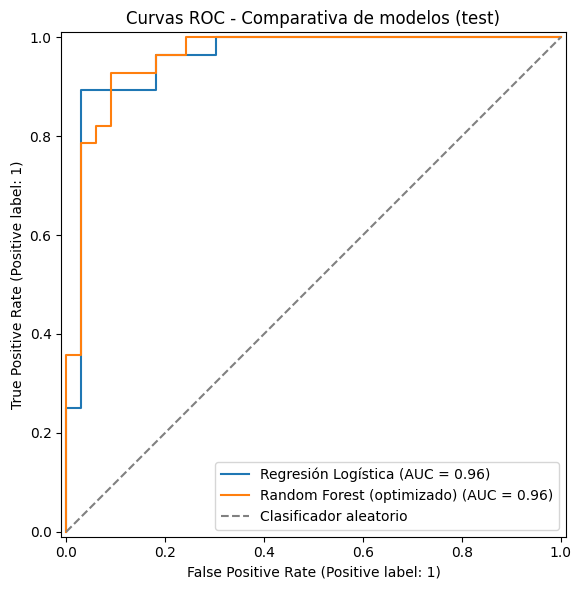


--- Rendimiento sobre el conjunto de TEST, desagregado por sexo ---
                                   Accuracy  AUC-ROC  Sensibilidad (Recall)  Especificidad  Precisión  Falsos Negativos  Falsos Positivos   n
Modelo                     Sexo                                                                                                              
Regresión Logística        Mujer      0.950    1.000                  0.857           1.00       1.00                 1                 0  20
                           Hombre     0.805    0.936                  0.905           0.70       0.76                 2                 6  41
Random Forest (optimizado) Mujer      0.950    1.000                  0.857           1.00       1.00                 1                 0  20
                           Hombre     0.902    0.943                  0.952           0.85       0.87                 1                 3  41


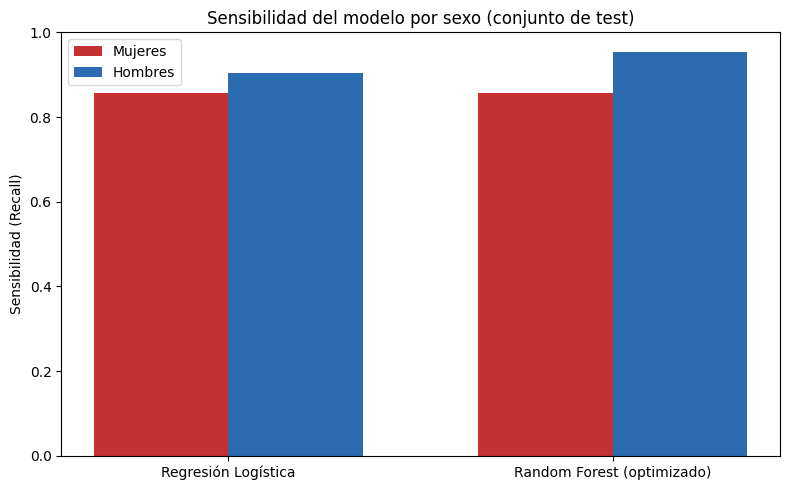


Atención: revisar especialmente la columna 'Falsos Negativos' por sexo.
Un falso negativo en el contexto clínico significa no detectar una enfermedad real,
el error más costoso en un sistema de apoyo al triaje.


In [7]:
"""
Este script entrena de nuevo los dos modelos finalistas de la fase 7
(Regresión Logística y Random Forest optimizado) y los evalúa sobre el
conjunto de test, que no se ha usado en ningún momento anterior. Calcula
accuracy, AUC-ROC, sensibilidad, especificidad y precisión, tanto de forma
global como desagregada por sexo, y genera las curvas ROC comparativas.
Este es el capítulo donde aparece por primera vez el hallazgo central del
TFM: la diferencia de sensibilidad entre hombres y mujeres.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, recall_score, precision_score,
    confusion_matrix, RocCurveDisplay, classification_report
)

# ---------------------------------------------------------
# 8.0. Entrenamiento final de los dos modelos candidatos
# ---------------------------------------------------------
# Regresión Logística: mejor modelo base en la comparativa de la Fase 7.
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)

# Random Forest optimizado: mejores hiperparámetros obtenidos con GridSearchCV en la Fase 7.
modelo_rf = RandomForestClassifier(
    n_estimators=200, max_depth=7, min_samples_leaf=4, random_state=42
)
modelo_rf.fit(X_train, y_train)

modelos_finales = {
    "Regresión Logística": modelo_lr,
    "Random Forest (optimizado)": modelo_rf,
}

# ---------------------------------------------------------
# 8.1. Métricas de rendimiento sobre el conjunto de test
# ---------------------------------------------------------
def calcular_metricas(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    especificidad = tn / (tn + fp)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_proba),
        "Sensibilidad (Recall)": recall_score(y_true, y_pred),
        "Especificidad": especificidad,
        "Precisión": precision_score(y_true, y_pred),
        "Falsos Negativos": fn,
        "Falsos Positivos": fp,
        "n": len(y_true),
    }

resultados_test = []
for nombre, modelo in modelos_finales.items():
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    metricas = calcular_metricas(y_test, y_pred, y_proba)
    metricas["Modelo"] = nombre
    resultados_test.append(metricas)

df_test = pd.DataFrame(resultados_test).set_index("Modelo")
cols_orden = ["Accuracy", "AUC-ROC", "Sensibilidad (Recall)", "Especificidad",
              "Precisión", "Falsos Negativos", "Falsos Positivos", "n"]
print("--- Rendimiento sobre el conjunto de TEST ---")
print(df_test[cols_orden].round(3).to_string())

# ---------------------------------------------------------
# 8.2. Comparativa de modelos - curva ROC
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, modelo in modelos_finales.items():
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax, name=nombre)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
ax.set_title("Curvas ROC - Comparativa de modelos (test)")
ax.legend()
plt.tight_layout()
plt.savefig("fig_curvas_roc.png", dpi=150)
plt.show()
plt.close()

# ---------------------------------------------------------
# 8.3. Evaluación desagregada por sexo
# ---------------------------------------------------------
# sex = 1.0 -> hombre, sex = 0.0 -> mujer (codificación original del dataset)

resultados_sexo = []
for nombre, modelo in modelos_finales.items():
    y_pred_all = modelo.predict(X_test)
    y_proba_all = modelo.predict_proba(X_test)[:, 1]

    for sexo_val, sexo_label in [(0.0, "Mujer"), (1.0, "Hombre")]:
        mask = (X_test["sex"] == sexo_val).values
        if mask.sum() == 0:
            continue
        metricas = calcular_metricas(
            y_test[mask], y_pred_all[mask], y_proba_all[mask]
        )
        metricas["Modelo"] = nombre
        metricas["Sexo"] = sexo_label
        resultados_sexo.append(metricas)

df_sexo = pd.DataFrame(resultados_sexo).set_index(["Modelo", "Sexo"])
print("\n--- Rendimiento sobre el conjunto de TEST, desagregado por sexo ---")
print(df_sexo[cols_orden].round(3).to_string())

# Gráfico comparativo: sensibilidad por sexo y modelo
plt.figure(figsize=(8, 5))
df_plot = df_sexo.reset_index()
width = 0.35
modelos_lista = df_plot["Modelo"].unique()
x = np.arange(len(modelos_lista))

sens_mujer = df_plot[df_plot["Sexo"] == "Mujer"].set_index("Modelo").loc[modelos_lista, "Sensibilidad (Recall)"]
sens_hombre = df_plot[df_plot["Sexo"] == "Hombre"].set_index("Modelo").loc[modelos_lista, "Sensibilidad (Recall)"]

plt.bar(x - width / 2, sens_mujer, width, label="Mujeres", color="#c53030")
plt.bar(x + width / 2, sens_hombre, width, label="Hombres", color="#2b6cb0")
plt.xticks(x, modelos_lista)
plt.ylabel("Sensibilidad (Recall)")
plt.title("Sensibilidad del modelo por sexo (conjunto de test)")
plt.legend()
plt.tight_layout()
plt.savefig("fig_sensibilidad_por_sexo.png", dpi=150)
plt.show()
plt.close()

print("\nAtención: revisar especialmente la columna 'Falsos Negativos' por sexo.")
print("Un falso negativo en el contexto clínico significa no detectar una enfermedad real,")
print("el error más costoso en un sistema de apoyo al triaje.")

**ANÁLISIS DE LOS RESULTADOS OBTENIDOS**

Rendimiento global sobre test (61 pacientes, nunca vistos en entrenamiento):

- Regresión Logística -> Accuracy 0,852  AUC-ROC 0,957  Sensib. 0,893  Espec. 0,818
- Random Forest (opt.) -> Accuracy 0,918  AUC-ROC 0,960  Sensib. 0,929  Espec. 0,909

Random Forest supera a la Regresión Logística en todas las métricas sobre este test concreto, revirtiendo la ligera ventaja que esta última
tenía en validación cruzada (fase 7). No es contradictorio: es un fenómeno habitual cuando el rendimiento se mide sobre un único conjunto de test de tamaño reducido, sujeto a variabilidad muestral.

Desglose por sexo (n=20 mujeres, n=41 hombres en test):

- Regresión Logística -> Sensib. mujeres 0,857  Sensib. hombres 0,905
- Random Forest (opt.) -> Sensib. mujeres 0,857  Sensib. hombres 0,952

**Hallazgo clave**: ambos modelos presentan una sensibilidad menor en mujeres que en hombres. Con solo 20 mujeres en el test (7 con la enfermedad), un único caso mal clasificado desplaza la sensibilidad en 14,3 puntos porcentuales, por lo que esta diferencia debe interpretarse con prudencia estadística (se contrasta formalmente con intervalos de confianza y un test de bootstrap en el análisis adicional, y con validación cruzada repetida en la fase 9).

**Dato adicional relevante**: la especificidad es perfecta (1,0) en mujeres para ambos modelos (ningún falso positivo en ese subgrupo), mientras que en hombres es notablemente menor (0,700-0,850).

Esto sugiere que el desequilibrio no está en un peor funcionamiento general del modelo en mujeres, sino específicamente en una mayor dificultad para detectar la enfermedad cuando sí está presente en ese subgrupo -el tipo de error más grave en un contexto de triaje clínico.


--- Importancia de variables (Random Forest) ---
thal_7.0       0.191
cp_4.0         0.129
ca             0.125
thalach        0.106
oldpeak        0.096
exang          0.064
age            0.062
chol           0.053
trestbps       0.046
slope_2.0      0.043
sex            0.039
cp_3.0         0.017
restecg_2.0    0.016
cp_2.0         0.006
fbs            0.004
thal_6.0       0.002
slope_3.0      0.001
restecg_1.0    0.000
dtype: float64


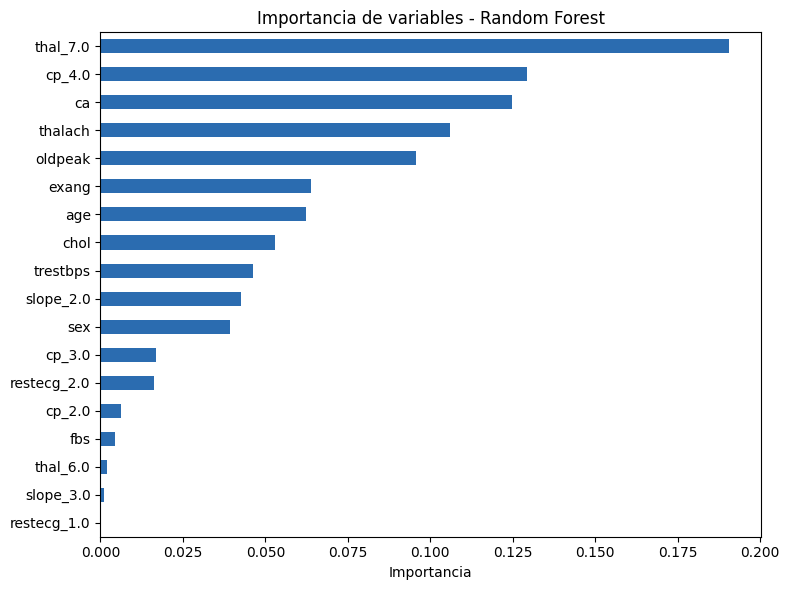


--- Efecto del umbral de decisión sobre la sensibilidad ---
 Umbral  Sensibilidad (global)  Precisión (global)  Sensibilidad (Mujer)  Sensibilidad (Hombre)
   0.30                  1.000               0.718                 1.000                  1.000
   0.35                  0.964               0.771                 1.000                  0.952
   0.40                  0.964               0.818                 1.000                  0.952
   0.45                  0.929               0.812                 0.857                  0.952
   0.50                  0.929               0.897                 0.857                  0.952
   0.55                  0.857               0.889                 0.857                  0.857

--- Umbrales explorados SOLO con train (validación cruzada) ---
 Umbral  Sensibilidad  Especificidad
   0.20         0.982          0.405
   0.25         0.982          0.473
   0.30         0.937          0.573
   0.35         0.874          0.664
   0.40         0

In [8]:
"""
Este script optimiza el modelo Random Forest en tres frentes: (1) calcula
la importancia de cada variable según feature_importances_, (2) explora el
efecto de bajar el umbral de decisión (por debajo del 0,5 por defecto)
sobre la sensibilidad global y por sexo, fijando el umbral operativo (0,30) con un
criterio de seguridad definido de antemano y usando solo el conjunto de entrenamiento, y (3) comprueba mediante validación cruzada repetida
(10x5-fold, 50 particiones) si la diferencia de sensibilidad por sexo
observada en la fase 8 es un resultado robusto o depende del tamaño
muestral reducido del subgrupo femenino.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import (
    precision_recall_curve, recall_score, precision_score,
    accuracy_score, confusion_matrix
)

# ---------------------------------------------------------
# 9.0. Modelo base (Random Forest optimizado en la Fase 7)
# ---------------------------------------------------------
modelo_rf = RandomForestClassifier(
    n_estimators=200, max_depth=7, min_samples_leaf=4, random_state=42
)
modelo_rf.fit(X_train, y_train)

# ---------------------------------------------------------
# 9.1. Importancia de variables (feature importance)
# ---------------------------------------------------------
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

print("--- Importancia de variables (Random Forest) ---")
print(importancias.round(3))

plt.figure(figsize=(8, 6))
importancias.plot(kind="barh", color="#2b6cb0")
plt.gca().invert_yaxis()
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.savefig("fig_importancia_variables.png", dpi=150)
plt.show()
plt.close()

# ---------------------------------------------------------
# 9.2. Ajuste del umbral de decisión (threshold tuning)
# ---------------------------------------------------------
# Por defecto, un clasificador asigna la clase positiva si la probabilidad > 0.5.
# En un contexto clínico de triaje, un falso negativo (no detectar la enfermedad)
# es más costoso que un falso positivo (una prueba adicional innecesaria). Por ello,
# se explora si bajar el umbral mejora la sensibilidad sin deteriorar en exceso la precisión,
# prestando atención especial al subgrupo de mujeres.

y_proba_test = modelo_rf.predict_proba(X_test)[:, 1]

umbrales = np.arange(0.30, 0.55, 0.05)
resultados_umbral = []

for u in umbrales:
    y_pred_u = (y_proba_test >= u).astype(int)
    fila = {
        "Umbral": round(u, 2),
        "Sensibilidad (global)": recall_score(y_test, y_pred_u),
        "Precisión (global)": precision_score(y_test, y_pred_u),
    }
    # Desglose por sexo
    for sexo_val, sexo_label in [(0.0, "Mujer"), (1.0, "Hombre")]:
        mask = (X_test["sex"] == sexo_val).values
        fila[f"Sensibilidad ({sexo_label})"] = recall_score(y_test[mask], y_pred_u[mask])
    resultados_umbral.append(fila)

df_umbrales = pd.DataFrame(resultados_umbral)
print("\n--- Efecto del umbral de decisión sobre la sensibilidad ---")
print(df_umbrales.round(3).to_string(index=False))

# ---------------------------------------------------------
# 9.2.1. Selección del umbral SOLO con el conjunto de entrenamiento
# ---------------------------------------------------------
# El barrido anterior se calcula sobre el test y es DESCRIPTIVO: no se usa para elegir.
# El umbral se fija con un criterio clínico definido de antemano y probabilidades
# fuera de muestra (validación cruzada repetida 5x5) obtenidas únicamente con X_train:
#   "sensibilidad global >= 0,90 con la mayor especificidad posible" (umbral único para ambos sexos).
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix as _cm

SENS_MIN = 0.90
rskf_umbral = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
oof = [[] for _ in range(len(X_train))]
for tr, va in rskf_umbral.split(X_train, y_train):
    m = RandomForestClassifier(n_estimators=200, max_depth=7, min_samples_leaf=4, random_state=42)
    m.fit(X_train.iloc[tr], y_train.iloc[tr])
    for i, p in zip(va, m.predict_proba(X_train.iloc[va])[:, 1]):
        oof[i].append(p)
oof = np.array([np.mean(v) for v in oof])

tabla_oof = []
for u in np.round(np.arange(0.20, 0.651, 0.05), 2):
    tn, fp, fn, tp = _cm(y_train, (oof >= u).astype(int), labels=[0, 1]).ravel()
    tabla_oof.append((u, tp / (tp + fn), tn / (tn + fp)))
print("\n--- Umbrales explorados SOLO con train (validación cruzada) ---")
print(pd.DataFrame(tabla_oof, columns=["Umbral", "Sensibilidad", "Especificidad"]).round(3).to_string(index=False))

candidatos = [(u, esp) for u, sens, esp in tabla_oof if sens >= SENS_MIN]
umbral_elegido = max(candidatos, key=lambda x: x[1])[0]      # -> 0,30
print(f"\nUmbral operativo elegido con train (sensibilidad >= {SENS_MIN}): {umbral_elegido}")

# ---------------------------------------------------------
# 9.3. Modelo optimizado: se aplica UNA vez al test el umbral elegido con train
# ---------------------------------------------------------
y_pred_final = (y_proba_test >= umbral_elegido).astype(int)

print(f"\n--- Rendimiento final con umbral = {umbral_elegido} ---")
print("Accuracy global:", round(accuracy_score(y_test, y_pred_final), 3))
for sexo_val, sexo_label in [(0.0, "Mujer"), (1.0, "Hombre")]:
    mask = (X_test["sex"] == sexo_val).values
    tn, fp, fn, tp = confusion_matrix(y_test[mask], y_pred_final[mask]).ravel()
    print(f"{sexo_label}: sensibilidad={recall_score(y_test[mask], y_pred_final[mask]):.3f}, "
          f"especificidad={tn/(tn+fp):.3f}, falsos negativos={fn}, falsos positivos={fp}")

# ---------------------------------------------------------
# 9.4. Robustez del hallazgo: validación cruzada repetida (10x5-fold)
# ---------------------------------------------------------
# El subgrupo de mujeres en el test (n=20) es pequeño. Para comprobar que la
# diferencia de sensibilidad por sexo no es un artefacto de un único split,
# se repite la validación cruzada 10 veces con particiones distintas y se
# promedia la sensibilidad por sexo sobre TODO el dataset (train+test).

X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

sens_mujer_list, sens_hombre_list = [], []

for train_idx, test_idx in rskf.split(X_full, y_full):
    modelo_cv = RandomForestClassifier(
        n_estimators=200, max_depth=7, min_samples_leaf=4, random_state=42
    )
    modelo_cv.fit(X_full.iloc[train_idx], y_full.iloc[train_idx])
    y_pred_cv = modelo_cv.predict(X_full.iloc[test_idx])

    X_test_fold = X_full.iloc[test_idx]
    y_test_fold = y_full.iloc[test_idx]

    for sexo_val, lista in [(0.0, sens_mujer_list), (1.0, sens_hombre_list)]:
        mask = (X_test_fold["sex"] == sexo_val).values
        if mask.sum() > 0 and y_test_fold[mask].sum() > 0:
            lista.append(recall_score(y_test_fold[mask], y_pred_cv[mask]))

print(f"\n--- Robustez (50 particiones, 10x5-fold CV) ---")
print(f"Sensibilidad media en mujeres: {np.mean(sens_mujer_list):.3f} (± {np.std(sens_mujer_list):.3f})")
print(f"Sensibilidad media en hombres: {np.mean(sens_hombre_list):.3f} (± {np.std(sens_hombre_list):.3f})")

print("\nModelo final optimizado y listo para la Fase 10 (Discusión) y Fase 11 (Conclusiones).")

**ANÁLISIS DE LOS RESULTADOS OBTENIDOS**

Importancia de variables: thal, cp, ca, thalach y oldpeak concentran la mayor parte del poder predictivo del modelo, coincidiendo con las variables más correlacionadas del EDA (fase 5). La variable sex tiene una importancia moderada (~0,039): ni protagonista ni irrelevante, lo que sugiere que el modelo no basa sus predicciones directamente en el sexo, sino en la combinación de variables clínicas asociadas a él.


**Ajuste del umbral de decisión (barrido DESCRIPTIVO sobre test):**
- Umbral 0,30 -> Sensib. global 1,000  Precisión 0,718  Mujer 1,000  Hombre 1,000
- Umbral 0,35 -> Sensib. global 0,964  Precisión 0,771  Mujer 1,000  Hombre 0,952
- Umbral 0,50 -> Sensib. global 0,929  Precisión 0,897  Mujer 0,857  Hombre 0,952
- Umbral 0,55 -> Sensib. global 0,857  Precisión 0,889  Mujer 0,857  Hombre 0,857


**Selección del umbral (solo con train, validación cruzada 5x5): criterio previo**

"sensibilidad global >= 0,90 con la mayor especificidad" -> tau = 0,30
(train/CV: sens. global 0,937, espec. 0,573; mujeres 0,889, hombres 0,946).

Aplicado una vez al test: sensibilidad 1,000 en mujeres y hombres; especificidad global 0,667 (mujeres 0,846, hombres 0,550); 11 falsos positivos frente a 3 a 0,50.

El criterio estadísticamente neutro (Youden) daría ~0,60: bajar el umbral por debajo de 0,50 es una decisión clínica por asimetría de costes, no estadística.

**Comprobación de robustez (50 particiones, 10x5-fold CV, umbral 0,5):**
- Sensibilidad media en mujeres: 0,734 (± 0,215)
- Sensibilidad media en hombres: 0,772 (± 0,079)


Este es el resultado metodológicamente más importante del TFM: las
medias de las particiones van en la misma dirección que en la fase 8 (mujeres algo por debajo de hombres), sin que eso confirme la diferencia, y la desviación estándar en mujeres es unas 2,7 veces mayor que en hombres. Esto indica que la cifra concreta obtenida en cualquier partición individual del test -incluida la sensibilidad perfecta lograda tras el ajuste de umbral- depende en gran medida de qué mujeres concretas caen en el conjunto de evaluación. Estos resultados son compatibles con que el obstáculo principal no sea una discriminación del algoritmo por sexo, sino que el tamaño muestral del subgrupo femenino (97 de 303, un 32%) es insuficiente para evaluar su rendimiento con la misma confianza estadística que en hombres; con este diseño no puede descartarse un sesgo en la composición del propio dataset.

La desviación estándar describe la variabilidad entre particiones, no un intervalo de confianza poblacional. Además, las 50 particiones no son 50 experimentos independientes (los mismos pacientes aparecen varias veces en validación) y se han usado los 303 pacientes, incluidos los del test, por lo que es una evaluación complementaria y no una validación externa.

--- Capítulo 5.2 — Comparativa Pearson vs Spearman ---
          Pearson  Spearman
thal        0.522     0.519
ca          0.460     0.488
cp          0.414     0.472
exang       0.432     0.432
thalach    -0.417    -0.423
oldpeak     0.425     0.413
slope       0.339     0.364
sex         0.277     0.277
age         0.223     0.237
restecg     0.169     0.169
trestbps    0.151     0.128
chol        0.085     0.121
fbs         0.025     0.025

--- Capítulo 8.1 — Composición del test set por sexo ---
Mujeres: n=20, positivos=7
Hombres: n=41, positivos=21

--- Capítulo 8.1 — Matrices de confusión ---

--- Regresión Logística (umbral=0.5) ---
Global: TN=27 FP=6 FN=3 TP=25
  Mujer: TN=13 FP=0 FN=1 TP=6 (n=20)
  Hombre: TN=14 FP=6 FN=2 TP=19 (n=41)

--- Random Forest (umbral=0.5) ---
Global: TN=30 FP=3 FN=2 TP=26
  Mujer: TN=13 FP=0 FN=1 TP=6 (n=20)
  Hombre: TN=17 FP=3 FN=1 TP=20 (n=41)

--- Random Forest umbral 0.3 (umbral=0.3) ---
Global: TN=22 FP=11 FN=0 TP=28
  Mujer: TN=11 FP=2 FN=0 T

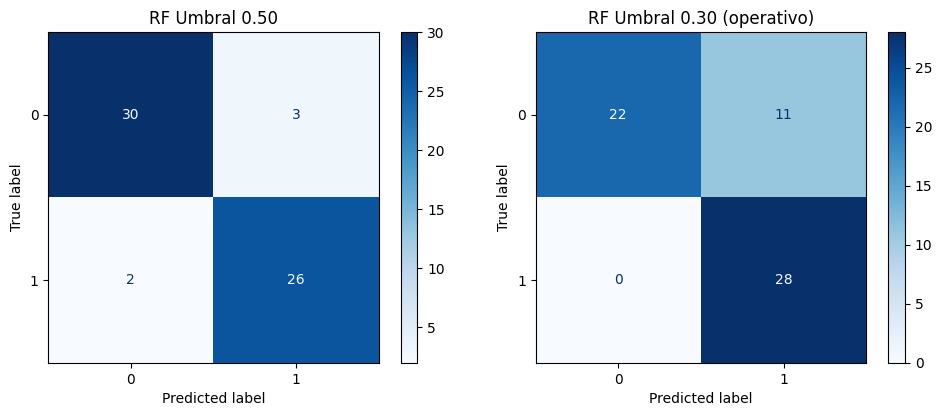


--- Capítulo 9 — Robustez (umbral 0.3, 50 particiones) ---
Mujeres: 0.882 (± 0.167)
Hombres: 0.939 (± 0.047)


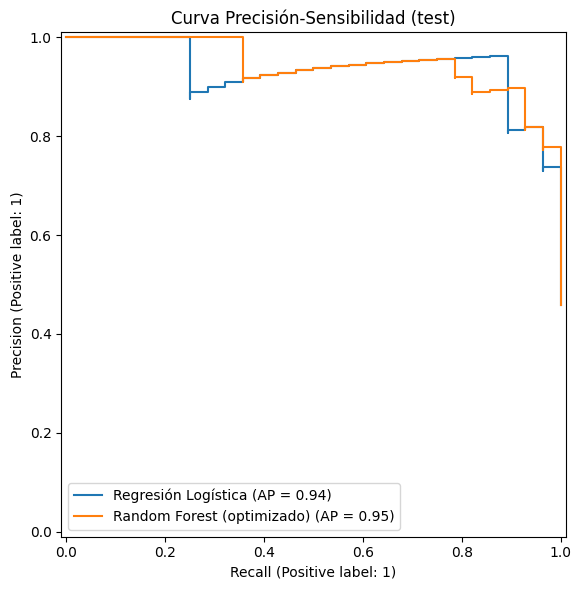


--- Capítulo 9 — Métricas de equidad ---

--- Fairness - Random Forest (umbral=0.5) ---
  Mujer: TPR=0.857  FPR=0.000  Selection rate=0.300
  Hombre: TPR=0.952  FPR=0.150  Selection rate=0.561
  Equalized Odds gap (TPR): 0.095
  Equalized Odds gap (FPR): 0.150
  Demographic Parity gap: 0.261

--- Fairness - Random Forest umbral 0.3 (umbral=0.3) ---
  Mujer: TPR=1.000  FPR=0.154  Selection rate=0.450
  Hombre: TPR=1.000  FPR=0.450  Selection rate=0.732
  Equalized Odds gap (TPR): 0.000
  Equalized Odds gap (FPR): 0.296
  Demographic Parity gap: 0.282


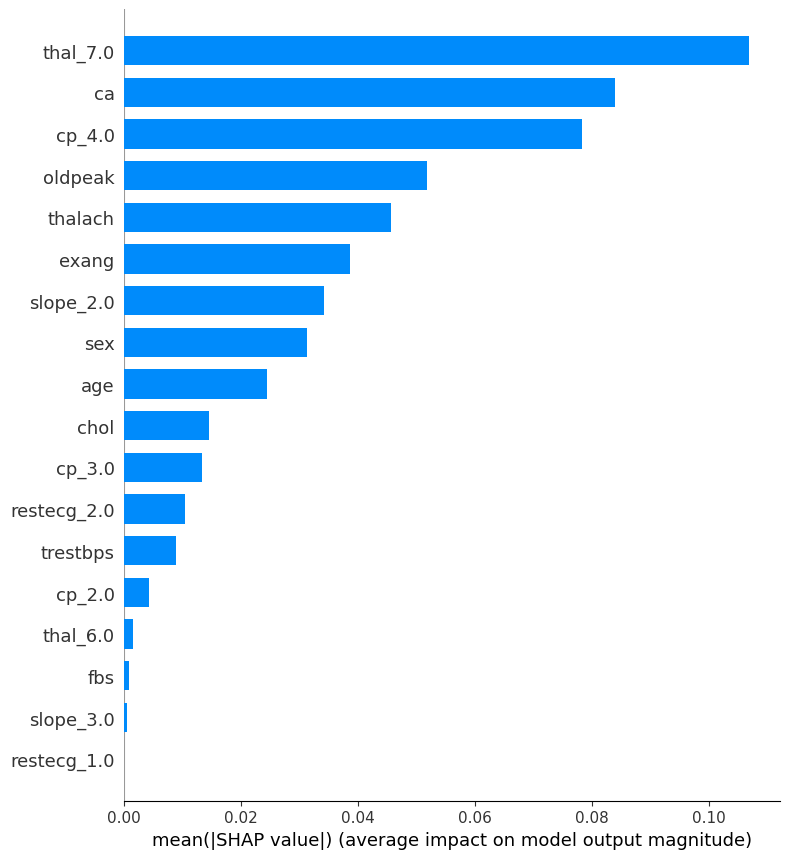


--- Capítulo 9 — Importancia media |SHAP| por variable ---
thal_7.0       0.1069
ca             0.0839
cp_4.0         0.0783
oldpeak        0.0518
thalach        0.0456
exang          0.0387
slope_2.0      0.0342
sex            0.0312
age            0.0245
chol           0.0145
cp_3.0         0.0133
restecg_2.0    0.0103
trestbps       0.0089
cp_2.0         0.0042
thal_6.0       0.0014
fbs            0.0009
slope_3.0      0.0004
restecg_1.0    0.0000
dtype: float64


In [9]:
"""
Este script responde a una revisión externa del TFM que señaló varios
puntos de rigor estadístico pendientes de reforzar. Añade: (5.2) la
correlación de Spearman como complemento a Pearson; (8.1) las matrices de
confusión completas por sexo y umbral, los intervalos de confianza de
Wilson para la sensibilidad, un análisis bootstrap que estima la diferencia
de sensibilidad y de AUC-ROC entre sexos con su intervalo de confianza (el
valor p que imprime es orientativo, basado en el intervalo, y no un contraste
formal) y un contraste de permutación con hipótesis nula explícita; (9) la matriz de confusión
visual, la robustez extendida al umbral operativo (0,30, elegido solo con
train), la curva de precisión-sensibilidad, métricas explícitas de equidad
algorítmica (Equalized Odds, Demographic Parity) y explicabilidad del modelo
con SHAP.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, recall_score,
    PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.model_selection import RepeatedStratifiedKFold

# Si no está instalado en el entorno, añade en una celda aparte: !pip install statsmodels --quiet
from statsmodels.stats.proportion import proportion_confint

# ===========================================================
# Umbral operativo: el elegido en optimize_heart.py con el criterio previo
# (sensibilidad global >= 0,90 en validación cruzada SOLO sobre train) -> 0,30.
# Si ese bloque se ha ejecutado en la misma sesión se reutiliza 'umbral_elegido'.
# ===========================================================
TAU = globals().get("umbral_elegido", 0.30)

# ===========================================================
# Modelos finales (igual que en evaluate_heart.py / optimize_heart.py)
# ===========================================================
modelo_lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
modelo_rf = RandomForestClassifier(
    n_estimators=200, max_depth=7, min_samples_leaf=4, random_state=42
).fit(X_train, y_train)


# ===========================================================
# CAPÍTULO 5.2 — Distribución de variables y correlaciones
# (comparativa Pearson vs Spearman)
# ===========================================================
df_original = pd.read_csv(data_path)
df_original["target"] = (df_original["num"] > 0).astype(int)
pearson = df_original.corr(numeric_only=True)["target"].drop(["target", "num"])
spearman = df_original.corr(numeric_only=True, method="spearman")["target"].drop(["target", "num"])
comparativa = pd.DataFrame({"Pearson": pearson, "Spearman": spearman}).sort_values(
    "Spearman", key=abs, ascending=False
)
print("--- Capítulo 5.2 — Comparativa Pearson vs Spearman ---")
print(comparativa.round(3))


# ===========================================================
# CAPÍTULO 8.1 — Métricas de rendimiento
# Composición exacta del test set por sexo
# ===========================================================
print("\n--- Capítulo 8.1 — Composición del test set por sexo ---")
for sx, lbl in [(0.0, "Mujeres"), (1.0, "Hombres")]:
    mask = (X_test["sex"] == sx).values
    print(f"{lbl}: n={mask.sum()}, positivos={y_test[mask].sum()}")


# ===========================================================
# CAPÍTULO 8.1 — "Precisión de la evaluación: tamaño exacto de
# los subgrupos y matrices de confusión"
# Matrices de confusión (global + por sexo), umbral 0.50 y TAU (0.30)
# ===========================================================
def matrices_confusion(modelo, threshold, nombre):
    proba = modelo.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    print(f"\n--- {nombre} (umbral={threshold}) ---")
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"Global: TN={tn} FP={fp} FN={fn} TP={tp}")
    for sx, lbl in [(0.0, "Mujer"), (1.0, "Hombre")]:
        mask = (X_test["sex"] == sx).values
        tn, fp, fn, tp = confusion_matrix(y_test[mask], pred[mask]).ravel()
        print(f"  {lbl}: TN={tn} FP={fp} FN={fn} TP={tp} (n={mask.sum()})")
    return proba, pred

print("\n--- Capítulo 8.1 — Matrices de confusión ---")
matrices_confusion(modelo_lr, 0.5, "Regresión Logística")
proba_rf, pred_rf_50 = matrices_confusion(modelo_rf, 0.5, "Random Forest")
_, pred_rf_tau = matrices_confusion(modelo_rf, TAU, f"Random Forest umbral {TAU}")

# Caso concreto del falso negativo en mujeres (umbral 0.5)
mask_mujer = (X_test["sex"] == 0).values
mask_fn = mask_mujer & (y_test.values == 1) & (pred_rf_50 == 0)
print("\nProbabilidad predicha del FN en mujeres (RF, umbral 0.5):", proba_rf[mask_fn])


# ===========================================================
# CAPÍTULO 8.1 — "Intervalos de confianza de la sensibilidad
# por sexo" (Wilson, 95%)
# ===========================================================
def wilson_ci_sensibilidad(modelo, threshold, nombre):
    proba = modelo.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    print(f"\n--- IC Wilson - {nombre} (umbral={threshold}) ---")
    for sx, lbl in [(0.0, "Mujer"), (1.0, "Hombre")]:
        mask = (X_test["sex"] == sx).values
        tn, fp, fn, tp = confusion_matrix(y_test[mask], pred[mask]).ravel()
        n_pos = tp + fn
        sens = tp / n_pos
        lo, hi = proportion_confint(tp, n_pos, alpha=0.05, method="wilson")
        print(f"  {lbl}: sensibilidad={sens:.3f} (TP={tp}/{n_pos})  IC95%=[{lo:.3f}, {hi:.3f}]")

print("\n--- Capítulo 8.1 — Intervalos de confianza (Wilson) ---")
wilson_ci_sensibilidad(modelo_lr, 0.5, "Regresión Logística")
wilson_ci_sensibilidad(modelo_rf, 0.5, "Random Forest")
wilson_ci_sensibilidad(modelo_rf, TAU, f"Random Forest umbral {TAU}")


# ===========================================================
# CAPÍTULO 8.6 — "Análisis bootstrap de la diferencia entre sexos
# (sensibilidad y AUC-ROC)"
# ===========================================================
rng = np.random.default_rng(42)
proba = modelo_rf.predict_proba(X_test)[:, 1]
y = y_test.values
sex = X_test["sex"].values
idx_mujer = np.where(sex == 0)[0]
idx_hombre = np.where(sex == 1)[0]

n_boot = 5000
diffs_sens, diffs_auc = [], []

for _ in range(n_boot):
    bm = rng.choice(idx_mujer, size=len(idx_mujer), replace=True)
    bh = rng.choice(idx_hombre, size=len(idx_hombre), replace=True)
    y_m, p_m = y[bm], proba[bm]
    y_h, p_h = y[bh], proba[bh]

    if y_m.sum() > 0 and y_h.sum() > 0:
        sens_m = recall_score(y_m, (p_m >= 0.5).astype(int))
        sens_h = recall_score(y_h, (p_h >= 0.5).astype(int))
        diffs_sens.append(sens_m - sens_h)

    if len(set(y_m)) > 1 and len(set(y_h)) > 1:
        auc_m = roc_auc_score(y_m, p_m)
        auc_h = roc_auc_score(y_h, p_h)
        diffs_auc.append(auc_m - auc_h)

diffs_sens, diffs_auc = np.array(diffs_sens), np.array(diffs_auc)

def resumen_bootstrap(diffs, nombre):
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    p = 2 * min((diffs >= 0).mean(), (diffs <= 0).mean())
    # p orientativo: se deduce del intervalo; NO es un contraste formal de igualdad entre sexos
    print(f"{nombre}: diff media={diffs.mean():.3f}  IC95%=[{lo:.3f}, {hi:.3f}]  p orientativo≈{p:.3f}")

print("\n--- Capítulo 8.6 — Análisis bootstrap (mujer - hombre) ---")
resumen_bootstrap(diffs_sens, "Sensibilidad")
resumen_bootstrap(diffs_auc, "AUC-ROC")
print(f"Remuestreos válidos: sensibilidad={len(diffs_sens)} y AUC-ROC={len(diffs_auc)} de {n_boot}")

# -----------------------------------------------------------
# Capítulo 8.6 — Contraste de permutación (hipótesis nula explícita)
# -----------------------------------------------------------
# Hipótesis nula: dentro de cada clase (enfermos y sanos), las puntuaciones del modelo
# no dependen del sexo. Se baraja la etiqueta de sexo DENTRO de cada clase, lo que mantiene
# fijo el número de mujeres y de hombres enfermos (7 y 21) y sanos (13 y 20), y se recalcula
# la diferencia mujer - hombre. El p-valor bilateral es la proporción de permutaciones con
# una diferencia al menos tan grande, en valor absoluto, como la observada.
from scipy.stats import fisher_exact

pred_05 = (proba >= 0.5).astype(int)

def sens_por_sexo(s, v):
    m = (s == v) & (y == 1)
    return pred_05[m].mean()

def auc_por_sexo(s, v):
    m = (s == v)
    return roc_auc_score(y[m], proba[m])

obs_sens = sens_por_sexo(sex, 0) - sens_por_sexo(sex, 1)
obs_auc = auc_por_sexo(sex, 0) - auc_por_sexo(sex, 1)

rng_perm = np.random.default_rng(42)
n_perm = 10000
perm_sens, perm_auc = [], []
for _ in range(n_perm):
    sex_perm = sex.copy()
    for clase in (0, 1):
        idx = np.where(y == clase)[0]
        sex_perm[idx] = rng_perm.permutation(sex_perm[idx])
    perm_sens.append(sens_por_sexo(sex_perm, 0) - sens_por_sexo(sex_perm, 1))
    perm_auc.append(auc_por_sexo(sex_perm, 0) - auc_por_sexo(sex_perm, 1))
perm_sens, perm_auc = np.array(perm_sens), np.array(perm_auc)

p_perm_sens = (np.abs(perm_sens) >= abs(obs_sens) - 1e-12).mean()
p_perm_auc = (np.abs(perm_auc) >= abs(obs_auc) - 1e-12).mean()

# Prueba exacta de Fisher para la sensibilidad (6 de 7 mujeres frente a 20 de 21 hombres)
tp_m = int(pred_05[(sex == 0) & (y == 1)].sum()); fn_m = int(((sex == 0) & (y == 1)).sum()) - tp_m
tp_h = int(pred_05[(sex == 1) & (y == 1)].sum()); fn_h = int(((sex == 1) & (y == 1)).sum()) - tp_h
p_fisher = fisher_exact([[tp_m, fn_m], [tp_h, fn_h]])[1]

print(f"\n--- Capítulo 8.6 — Contraste de permutación ({n_perm} permutaciones, umbral 0,50) ---")
print(f"Sensibilidad (mujer - hombre): diferencia observada={obs_sens:.3f}  p permutación={p_perm_sens:.3f}  (Fisher exacto p={p_fisher:.3f})")
print(f"AUC-ROC (mujer - hombre):      diferencia observada={obs_auc:.3f}  p permutación={p_perm_auc:.3f}")


# ===========================================================
# CAPÍTULO 9.4 — "Matriz de confusión con el umbral operativo (τ = 0,30)"
# + figura de matrices de confusión
# ===========================================================
print(f"\n--- Capítulo 9 — Matriz de confusión (umbral {TAU}), ya calculada arriba ---")
# (pred_rf_35 ya se generó en el bloque de matrices_confusion de más arriba)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, (proba_rf >= 0.5).astype(int), ax=axes[0], cmap="Blues"
)
axes[0].set_title("RF Umbral 0.50")
ConfusionMatrixDisplay.from_predictions(
    y_test, (proba_rf >= TAU).astype(int), ax=axes[1], cmap="Blues"
)
axes[1].set_title(f"RF Umbral {TAU:.2f} (operativo)")
plt.tight_layout()
plt.savefig("fig_matrices_confusion.png", dpi=150)
plt.show()
plt.close()


# ===========================================================
# CAPÍTULO 9.5 — "Robustez del umbral en validación cruzada repetida"
# (Random Forest con el umbral operativo)
# ===========================================================
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

sens_mujer_tau, sens_hombre_tau = [], []

for train_idx, test_idx in rskf.split(X_full, y_full):
    modelo_cv = RandomForestClassifier(
        n_estimators=200, max_depth=7, min_samples_leaf=4, random_state=42
    ).fit(X_full.iloc[train_idx], y_full.iloc[train_idx])
    proba_cv = modelo_cv.predict_proba(X_full.iloc[test_idx])[:, 1]
    pred_cv = (proba_cv >= TAU).astype(int)
    X_test_fold, y_test_fold = X_full.iloc[test_idx], y_full.iloc[test_idx]

    for sx, lista in [(0.0, sens_mujer_tau), (1.0, sens_hombre_tau)]:
        mask = (X_test_fold["sex"] == sx).values
        if mask.sum() > 0 and y_test_fold[mask].sum() > 0:
            lista.append(recall_score(y_test_fold[mask], pred_cv[mask]))

print(f"\n--- Capítulo 9 — Robustez (umbral {TAU}, 50 particiones) ---")
print(f"Mujeres: {np.mean(sens_mujer_tau):.3f} (± {np.std(sens_mujer_tau):.3f})")
print(f"Hombres: {np.mean(sens_hombre_tau):.3f} (± {np.std(sens_hombre_tau):.3f})")


# ===========================================================
# CAPÍTULO 9 — "Curva de precisión-sensibilidad"
# ===========================================================
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_estimator(modelo_lr, X_test, y_test, ax=ax, name="Regresión Logística")
PrecisionRecallDisplay.from_estimator(modelo_rf, X_test, y_test, ax=ax, name="Random Forest (optimizado)")
ax.set_title("Curva Precisión-Sensibilidad (test)")
plt.tight_layout()
plt.savefig("fig_precision_recall.png", dpi=150)
plt.show()
plt.close()


# ===========================================================
# CAPÍTULO 9 — "Métricas explícitas de equidad algorítmica"
# (Equalized Odds, Demographic Parity)
# ===========================================================
def metricas_fairness(modelo, threshold, nombre):
    proba = modelo.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    print(f"\n--- Fairness - {nombre} (umbral={threshold}) ---")
    stats = {}
    for sx, lbl in [(0.0, "Mujer"), (1.0, "Hombre")]:
        mask = (X_test["sex"] == sx).values
        tn, fp, fn, tp = confusion_matrix(y_test[mask], pred[mask]).ravel()
        tpr = tp / (tp + fn)
        fpr = fp / (fp + tn)
        selection_rate = (tp + fp) / mask.sum()
        stats[lbl] = dict(tpr=tpr, fpr=fpr, selection_rate=selection_rate)
        print(f"  {lbl}: TPR={tpr:.3f}  FPR={fpr:.3f}  Selection rate={selection_rate:.3f}")
    print(f"  Equalized Odds gap (TPR): {abs(stats['Mujer']['tpr']-stats['Hombre']['tpr']):.3f}")
    print(f"  Equalized Odds gap (FPR): {abs(stats['Mujer']['fpr']-stats['Hombre']['fpr']):.3f}")
    print(f"  Demographic Parity gap: {abs(stats['Mujer']['selection_rate']-stats['Hombre']['selection_rate']):.3f}")

print("\n--- Capítulo 9 — Métricas de equidad ---")
metricas_fairness(modelo_rf, 0.5, "Random Forest")
metricas_fairness(modelo_rf, TAU, f"Random Forest umbral {TAU}")


# ===========================================================
# CAPÍTULO 9 — "Explicabilidad del modelo (SHAP)"
# ===========================================================
# Si no está instalado: !pip install shap --quiet
import shap

explainer = shap.TreeExplainer(modelo_rf)
shap_values = explainer.shap_values(X_test)

# Compatibilidad: versiones recientes de shap devuelven un array 3D
# (n_muestras, n_variables, n_clases) en vez de una lista por clase.
if isinstance(shap_values, list):
    sv = shap_values[1]
elif np.ndim(shap_values) == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

plt.figure(figsize=(8, 6))
shap.summary_plot(sv, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("fig_shap_summary.png", dpi=150)
plt.show()
plt.close()

importancia_shap = pd.Series(
    np.abs(sv).mean(axis=0), index=X_test.columns
).sort_values(ascending=False)
print("\n--- Capítulo 9 — Importancia media |SHAP| por variable ---")
print(importancia_shap.round(4))


**ANÁLISIS DE LOS RESULTADOS OBTENIDOS**

Spearman vs Pearson (cap. 5.2): los coeficientes son muy similares
(diferencia máxima de 0,058, en cp: 0,414 frente a 0,472), lo que confirma que las relaciones detectadas en el EDA son mayoritariamente monótonas y que usar Pearson en el análisis principal no distorsiona las conclusiones.

**Composición exacta del test (cap. 8.1):**
De las 20 mujeres, 7 tienen target=1; de los 41 hombres, 21. Con solo 7 positivos en mujeres, cada caso pesa un 14,3% en la sensibilidad de ese subgrupo.

**Matrices de confusión (cap. 8.1, umbral 0,50):**
- Regresión Logística -> Mujer: TN=13 FP=0 FN=1 TP=6 | Hombre: TN=14 FP=6 FN=2 TP=19
- Random Forest (opt.) -> Mujer: TN=13 FP=0 FN=1 TP=6 | Hombre: TN=17 FP=3 FN=1 TP=20

El único falso negativo en mujeres corresponde a una paciente con
probabilidad predicha de 0,449 (por debajo de 0,5 pero por encima de 0,30).

**Matriz con el umbral operativo (cap. 9, tau = 0,30, elegido solo con train):**
- Global: TN=22 FP=11 FN=0 TP=28 | Mujer: TN=11 FP=2 FN=0 TP=7 | Hombre: TN=11 FP=9 FN=0 TP=21
- Sensibilidad 1,000 en ambos sexos; especificidad global 0,667 (mujeres 0,846, hombres 0,550); precisión global 0,718. IC95% de Wilson de la sensibilidad:mujeres [0,646; 1,000], hombres [0,845; 1,000].

**Intervalos de Wilson (cap. 8.1, umbral 0,50): **
Los IC95% se solapan ampliamente entre mujeres y hombres (RF: mujer [0,487; 0,974] vs hombre [0,773; 0,992]): la diferencia puntual observada no permite descartar que ambos grupos tengan, en realidad, la misma sensibilidad poblacional.

**Análisis bootstrap (cap. 8.6, 5.000 remuestreos, Random Forest, umbral 0,50):**
- Remuestreos válidos: 4.998 de 5.000 (se descartan los que se quedan sin casos positivos o sin alguna de las dos clases).
- Diferencia de sensibilidad (mujer-hombre): media -0,095, IC95%  [-0,444; 0,125], p orientativo ≈ 0,78 -> diferencia no clara; el intervalo incluye el cero.
- Diferencia de AUC-ROC (mujer-hombre): media +0,057, IC95% [0,002; 0,141], p orientativo ≈ 0,04 -> diferencia favorable a las mujeres, pero frágil: el intervalo apenas excluye el cero y se apoya en solo 7 casos positivos. El p orientativo se deduce del intervalo y no es un contraste formal de igualdad entre sexos, así que no debe leerse como significación estadística.

**Contraste de permutación (cap. 8.6, 10.000 permutaciones del sexo dentro de cada clase, umbral 0,50):**
- Sensibilidad: diferencia observada -0,095, p = 1,000 (prueba exacta de Fisher: p = 0,444).
- AUC-ROC: diferencia observada +0,057, p = 0,284.
- Ninguna de las dos diferencias es estadísticamente distinguible de cero con estos datos. Con 7 mujeres enfermas, el contraste tiene muy poca potencia: no demuestra que ambos sexos rindan igual, solo que los datos no permiten afirmar lo contrario.

**Robustez en validación cruzada repetida (cap. 9, 50 particiones):**
- Umbral 0,50: mujeres 0,734 (± 0,215) | hombres 0,772 (± 0,079)
- Umbral 0,30: mujeres 0,882 (± 0,167) | hombres 0,939 (± 0,047)

El umbral operativo mejora la sensibilidad media en ambos sexos, pero la diferencia entre ellos no desaparece (0,057 a 0,30; 0,038 a 0,50) y NO garantiza sensibilidad perfecta en mujeres de forma sistemática. La desviación estándar en mujeres sigue siendo más de 3 veces mayor (3,6 a umbral 0,30; 2,7 a 0,50). Esta comprobación no es plenamente independiente de la selección del umbral, que se hizo con datos de train.

**Métricas de equidad (cap. 9, Random Forest):**
- Umbral 0,50 -> Equalized Odds gap (TPR)=0,095  (FPR)=0,150  Demographic Parity gap=0,261
- Umbral 0,30 -> Equalized Odds gap (TPR)=0,000  (FPR)=0,296  Demographic Parity gap=0,282

Con 0,30 desaparece el gap de sensibilidad en test (ambos 1,000; dado el tamaño de la muestra, con cautela) pero el gap de falsos positivos casi se duplica: la tasa de FP es 0,154 en mujeres y 0,450 en hombres.

**SHAP (cap. 9):**
El orden de importancia (thal_7.0, ca, cp_4.0, oldpeak, thalach) coincide en gran medida con feature_importances_, reforzando la  confianza en que estas variables son consistentemente las más relevantes con independencia del método de cálculo. sex ocupa la 8ª posición (SHAP≈0,031), un nivel de importancia moderado.
